# Customer Churn Analysis

ML and Visualisation assignment - Tasks 1 and 2.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### Load data

In [2]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')
print(df.shape)
df.head()

(440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


### Check missing

In [3]:
print(df.dtypes)
print()
print(df.isnull().sum())

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [4]:
# drop the one NaN row and CustomerID
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=['CustomerID'])
print(df.shape)
df.describe()

(440832, 11)


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Churn distribution

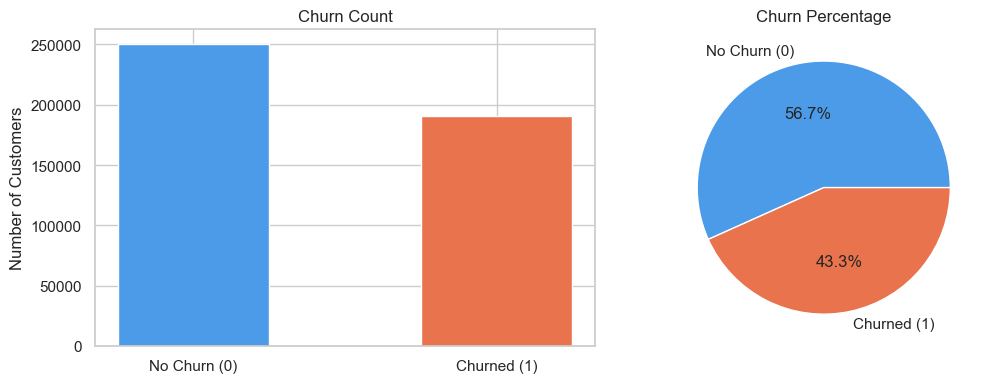

Churn rate: 56.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_counts = df['Churn'].value_counts()
labels = ['No Churn (0)', 'Churned (1)']
colors = ['#4c9be8', '#e8734c']

axes[0].bar(labels, churn_counts.values, color=colors, width=0.5)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts.values, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.savefig('fig1_churn_distribution.png')
plt.show()

print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

### Numerical features

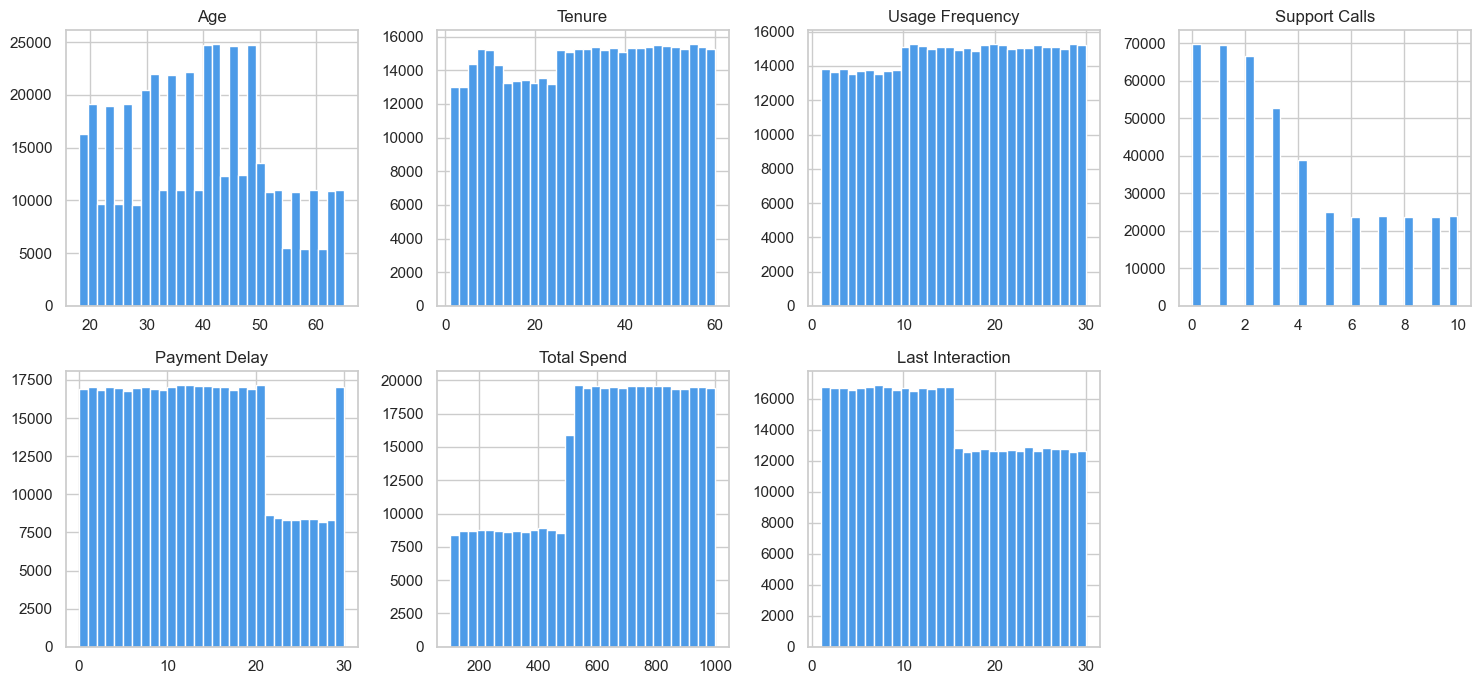

In [6]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#4c9be8', edgecolor='white')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_numerical_distributions.png')
plt.show()

### Churn rate by category

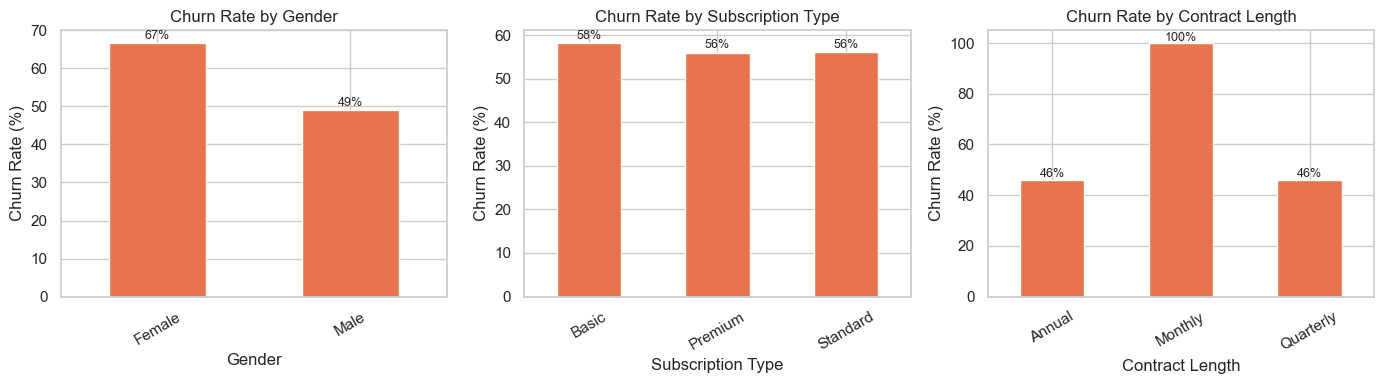

Churn rate by Contract Length:
Contract Length
Annual        46.076141
Monthly      100.000000
Quarterly     46.025605
Name: Churn, dtype: float64


In [7]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='#e8734c', width=0.5)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{bar.get_height():.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_churn_by_category.png')
plt.show()

print('Churn rate by Contract Length:')
print(df.groupby('Contract Length')['Churn'].mean() * 100)

### Boxplots vs churn

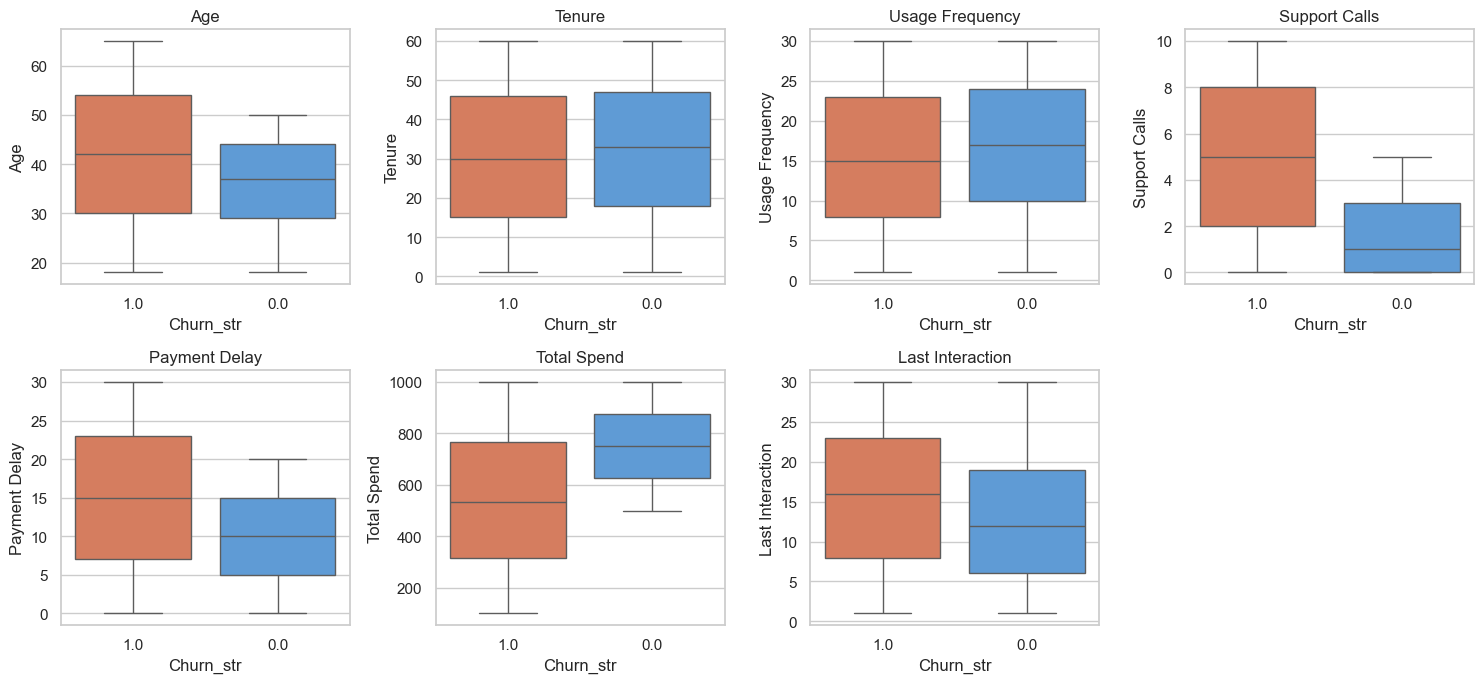

In [8]:
df['Churn_str'] = df['Churn'].astype(str)
palette = {'0.0': '#4c9be8', '1.0': '#e8734c'}

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn_str', y=col, ax=axes[i], palette=palette)
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_boxplots_vs_churn.png')
plt.show()

### Correlation heatmap

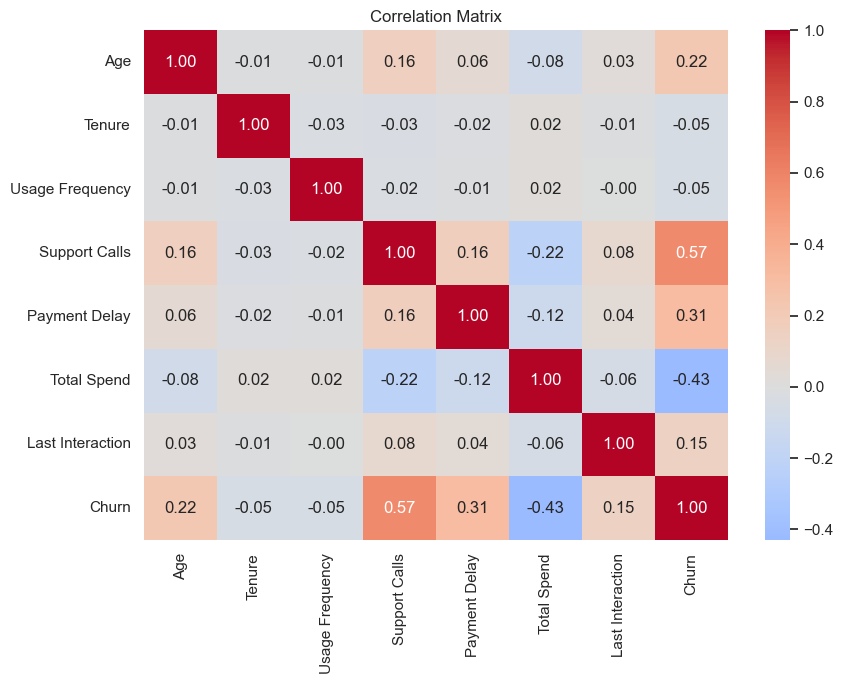

Total Spend        -0.429355
Tenure             -0.051919
Usage Frequency    -0.046101
Last Interaction    0.149616
Age                 0.218394
Payment Delay       0.312129
Support Calls       0.574267
Name: Churn, dtype: float64


In [9]:
corr = df[num_cols + ['Churn']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png')
plt.show()

print(corr['Churn'].drop('Churn').sort_values())

### Churn rate by support calls

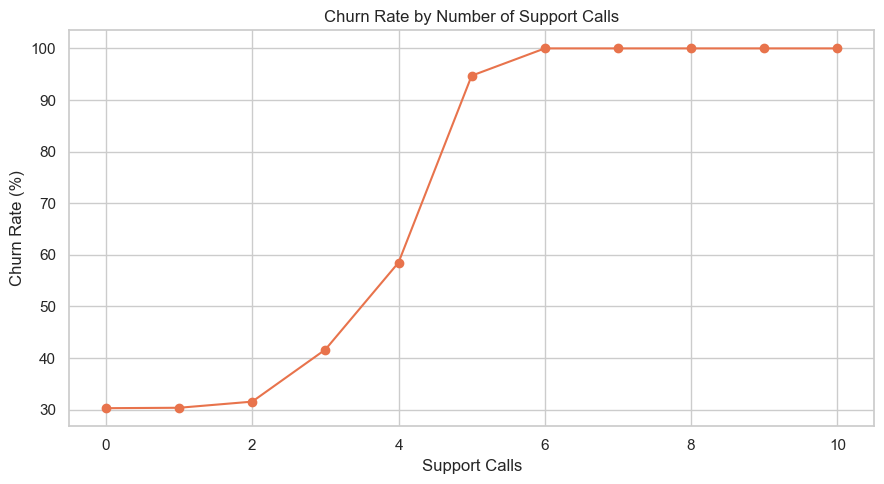

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
churn_by_calls = df.groupby('Support Calls')['Churn'].mean() * 100
churn_by_calls.plot(kind='line', marker='o', color='#e8734c', ax=ax)
ax.set_title('Churn Rate by Number of Support Calls')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Support Calls')
plt.tight_layout()
plt.savefig('fig6_churn_by_support_calls.png')
plt.show()

### Encode categoricals

In [11]:
df_ml = df.drop(columns=['Churn_str']).copy()

le = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0


### Train/test split + scaling

In [12]:
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train:', X_train.shape[0])
print('Test:', X_test.shape[0])

Train: 352665
Test: 88167


### Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8504

              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83     38063
         1.0       0.88      0.85      0.87     50104

    accuracy                           0.85     88167
   macro avg       0.85      0.85      0.85     88167
weighted avg       0.85      0.85      0.85     88167



### Random Forest with GridSearchCV

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_base, param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

rf = grid.best_estimator_
print(grid.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
{'max_depth': None, 'n_estimators': 200}


In [15]:
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9998

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38063
         1.0       1.00      1.00      1.00     50104

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



### Confusion matrices

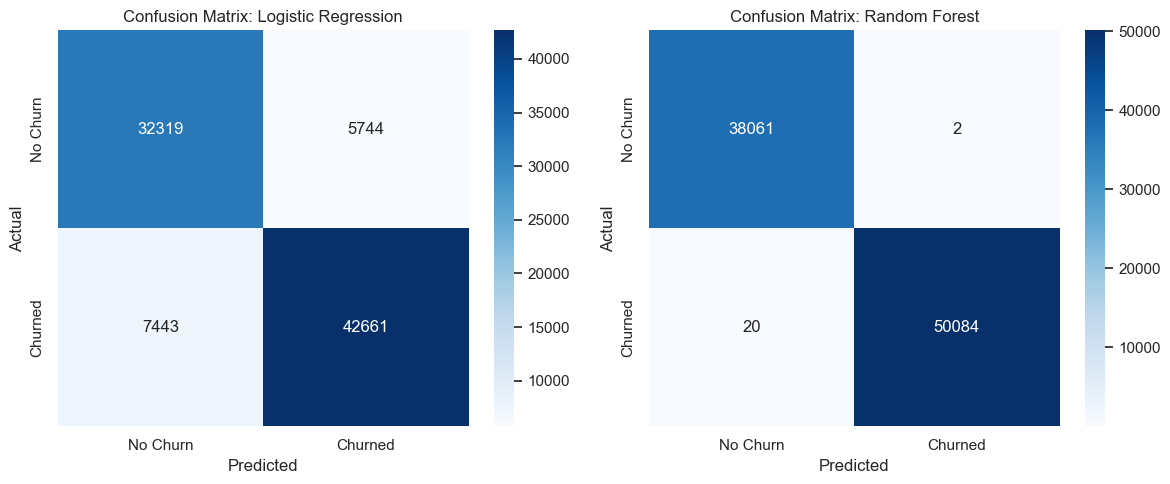

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'])
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png')
plt.show()

### Feature importance

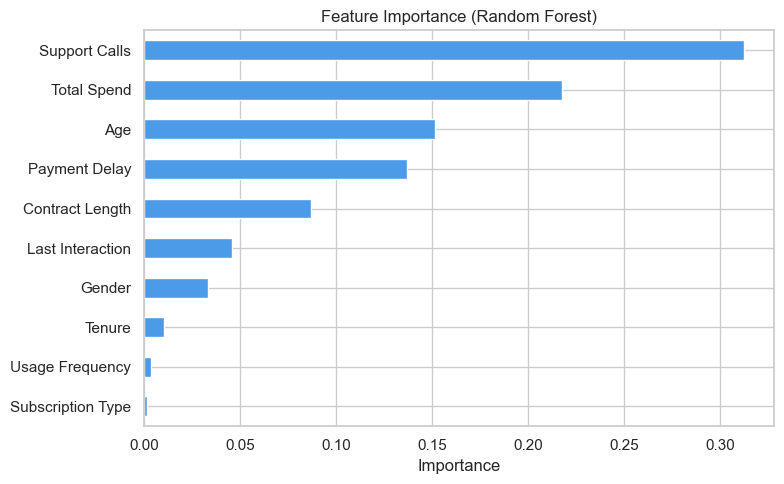

Support Calls        0.312636
Total Spend          0.217796
Age                  0.151449
Payment Delay        0.136817
Contract Length      0.086873
Last Interaction     0.045818
Gender               0.033423
Tenure               0.010252
Usage Frequency      0.003371
Subscription Type    0.001565
dtype: float64


In [17]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#4c9be8')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png')
plt.show()

print(feat_imp.sort_values(ascending=False))

### K-Means

In [18]:
cluster_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                    'Payment Delay', 'Total Spend', 'Last Interaction']

X_cluster = scaler.fit_transform(df[cluster_features])

#### Elbow method

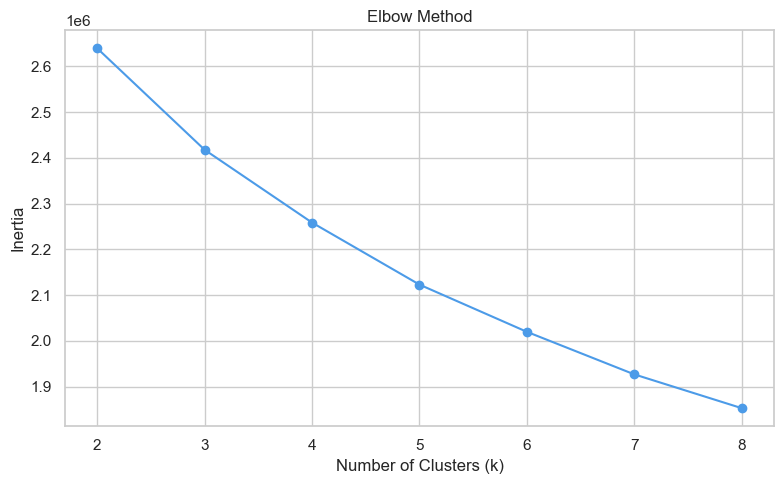

In [19]:
inertia = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertia, marker='o', color='#4c9be8')
ax.set_title('Elbow Method')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('fig9_elbow_method.png')
plt.show()
# bends around k=4

#### Fit k=4

In [20]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_cluster)

print(df['Cluster'].value_counts().sort_index())
print()
df.groupby('Cluster')[cluster_features + ['Churn']].mean().round(2)

Cluster
0    120961
1     81262
2    139732
3     98877
Name: count, dtype: int64



,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Cluster,,,,,,,,
0,36.60,15.54,18.63,1.98,10.43,733.56,13.35,0.31
1,29.82,30.45,15.12,6.57,17.40,447.07,16.35,0.99
2,36.33,45.79,14.09,1.89,10.29,735.59,13.18,0.26
3,54.92,30.60,15.34,5.57,16.20,511.64,16.17,0.96


#### Cluster scatter (sample)

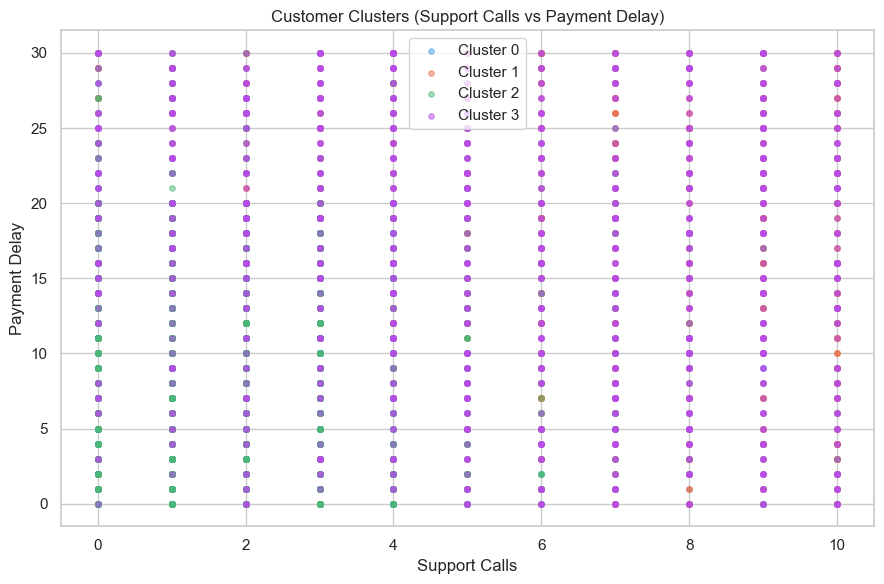

In [21]:
# take a sample for plotting (full dataset would be too many dots)
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
colors_cluster = ['#4c9be8', '#e8734c', '#4cb87a', '#b84ce8']
for c in range(4):
    mask = sample['Cluster'] == c
    ax.scatter(sample.loc[mask, 'Support Calls'],
               sample.loc[mask, 'Payment Delay'],
               c=colors_cluster[c], s=15, alpha=0.5, label=f'Cluster {c}')
ax.set_xlabel('Support Calls')
ax.set_ylabel('Payment Delay')
ax.set_title('Customer Clusters (Support Calls vs Payment Delay)')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_kmeans_clusters.png')
plt.show()

#### Churn rate per cluster

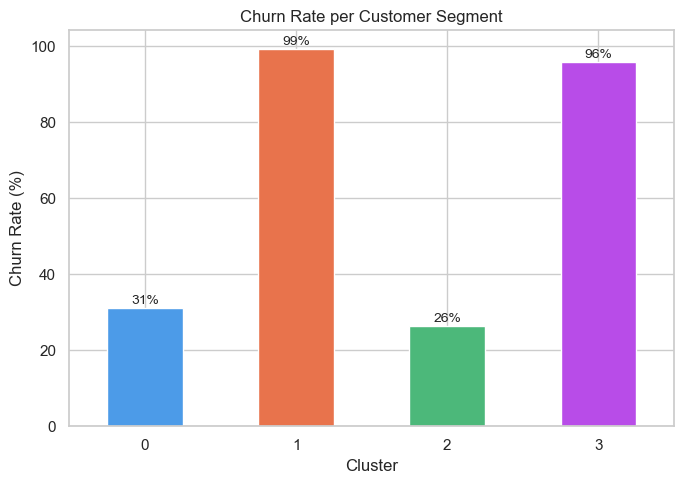

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
churn_per_cluster = df.groupby('Cluster')['Churn'].mean() * 100
churn_per_cluster.plot(kind='bar', ax=ax, color=colors_cluster, width=0.5)
ax.set_title('Churn Rate per Customer Segment')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Cluster')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig11_churn_per_cluster.png')
plt.show()

### Model comparison

In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [f'{acc_lr:.4f}', f'{acc_rf:.4f}']
})
print(results.to_string(index=False))

              Model Accuracy
Logistic Regression   0.8504
      Random Forest   0.9998


### Export for Tableau

In [24]:
df_export = df.drop(columns=['Churn_str']).copy()
df_export['Churn_Label'] = df_export['Churn'].map({0.0: 'Retained', 1.0: 'Churned'})
df_export.to_csv('churn_for_tableau.csv', index=False)
print(df_export.shape)

(440832, 13)
